# Сервис продажи авиабилетов


Есть 3 таблицы с данными.

Таблица `hiring_pa_task.pa_hiring_task` с данными по воронкам  c 3 по 14 июля 2022.\
Содержит данные о просмотрах экранов пользователями в виде событий (events).

№	|Название поля	|Описание
-|-|-
1	|date	|дата совершения события
2	|timestamp	|дата и время совершения события
3	|u_id	|уникальный идентификатор пользователя
4	|event	|название события, возможные значения мы привели в Задании 2
5	|d_cty_name	|название города отправления
6	|d_ctry_name	|название страны отправления
7	|d_cty_code	|код города отправления
8	|a_ctry_name	|название страны прибытия
9	|a_ctry_code	|код страны прибытия
10	|a_cty_name	|название города прибытия
11	|a_cty_code	|код города прибытия


Таблица `hiring_pa_task.pa_hiring_task_experiment_data`, где хранятся данные по эксперименту c 3 по 14 июля 2022.\
Содержит данные о пользователях, которые участвовали в тесте в виде событий (events).

№	|Название поля	|Описание
-|-|-
1	|u_id	|уникальный идентификатор пользователя
2	|event	|название события
3	|fork	|признак ветки (контрольная, тестовая)
4	|date	|дата совершения события

Таблица `hiring_pa_task.has_avia_transactions`, где хранятся идентификаторы пользователей, которые хотя бы раз совершали покупки.

№	|Название поля	|Описание
-|-|-
1	|u_id	|уникальный идентификатор пользователя

## Блок 1: SQL

### Задание 1

Определи топ-10 международных направлений (по городам), по которым пользователи ищут авиабилеты из Казахстана.

<pre style="background: #f5f5f5; padding: 10px">
SELECT a_cty_name,
       COUNT(a_cty_name) number_of_requests
FROM `hiring_pa_task.pa_hiring_task`
WHERE d_ctry_name IN ('Kazakhstan', 'Казахстан', 'Қазақстан')
  AND a_ctry_name NOT IN ('Kazakhstan', 'Казахстан', 'Қазақстан')
  AND a_ctry_name IS NOT NULL
  AND event = 'travel_search_results'
GROUP BY a_cty_name
ORDER BY number_of_requests DESC
LIMIT 10;
</pre>

|Row	| a_cty_name | number_of_requests|
| --- | --- | --- |
|1	| Стамбул	| 16454|
|2	| Кутаиси	| 8362|
|3	| Анталья	| 8230|
|4	| Сеул	| 8210|
|5	| Москва	| 7774|
|6	| Ташкент	| 5728|
|7	| Нукус	| 5133|
|8	| Тбилиси	| 4755|
|9	| Ургенч	| 4202|
|10	| Баку	| 3894|

### Задание 2

Построй воронку от просмотра формы поиска билета до покупки авиабилета. Основная воронка, которую проходит пользователь, состоит из 8 шагов.

<pre style="background: #f5f5f5; padding: 10px">
WITH 
<span style="color: #fc6f03">-- активность (date&u_id) - действия пользователя в конкретную дату в разных событиях
-- сокращаем названия событий и 2 события по оплате агрегируем в одно
-- создаём признаки: один потребуется для фиксации, где была активность;
-- ... маркеры международности и повторный ли клиент</span>
pre_table_1 AS
  (SELECT CASE
            WHEN event='travel_search_form'          THEN 'search_form'
            WHEN event='travel_search_in_progress'   THEN 'search_in_progress'
            WHEN event='travel_search_results'       THEN 'search_results'
            WHEN event='travel_flight_details'       THEN 'flight_details'
            WHEN event='travel_tariff_confirmation'  THEN 'tariff_confirmation'
            WHEN event='travel_select_passenger'     THEN 'select_passenger'
            WHEN event='travel_payment_method'       THEN 'payment_method'
            WHEN event IN ('travel_card_payment_approved', 
                           'travel_credit_approved') THEN 'transaction_approved'
            ELSE 'unknown_event'
          END event_grouped,
          CASE
            WHEN event='travel_search_form'          THEN          1
            WHEN event='travel_search_in_progress'   THEN         10
            WHEN event='travel_search_results'       THEN        100
            WHEN event='travel_flight_details'       THEN       1000
            WHEN event='travel_tariff_confirmation'  THEN      10000
            WHEN event='travel_select_passenger'     THEN     100000
            WHEN event='travel_payment_method'       THEN    1000000
            WHEN event IN ('travel_card_payment_approved', 
                           'travel_credit_approved') THEN   10000000
            ELSE                                          -100000000
          END event_grouped_num,
          CASE
            WHEN d_ctry_name NOT IN ('Kazakhstan', 'Казахстан', 'Қазақстан')
             AND d_ctry_name IS NOT NULL
              OR a_ctry_name NOT IN ('Kazakhstan', 'Казахстан', 'Қазақстан')
             AND a_ctry_name IS NOT NULL                                     THEN 1
            WHEN d_ctry_name     IN ('Kazakhstan', 'Казахстан', 'Қазақстан')
             AND a_ctry_name     IN ('Kazakhstan', 'Казахстан', 'Қазақстан') THEN 0
          END international,
          CASE
            WHEN u_id IN (SELECT u_id
                          FROM `hiring_pa_task.has_avia_transactions`) THEN 1
            ELSE 0
          END has_avia_transactions,
          timestamp,
          date,
          u_id
   FROM `hiring_pa_task.pa_hiring_task`),

<span style="color: #fc6f03">-- сохраняем активность только 1-ую за день в конкретном событии</span>
pre_table_2 AS
  (SELECT DISTINCT *
   FROM (SELECT *,
                MIN(timestamp) OVER(PARTITION BY event_grouped, date, u_id) min_timestamp
         FROM pre_table_1)
   WHERE timestamp = min_timestamp),

<span style="color: #fc6f03">-- новый признак агрегирует информацию в каких событиях была активность; 0 - нет, 1 - да
-- хронология справа налево; 
-- например, 110 - в search_form активности нет, а в след.двух есть</span>
pre_table_3 AS
  (SELECT *,
          SUM(event_grouped_num) OVER(PARTITION BY date, u_id) event_amount_feature
   FROM pre_table_2),

<span style="color: #fc6f03">-- перечень активностей
-- оставили запись только, если активность была во всех предыдущих событиях</span>
pre_table_4 AS
  (SELECT event_grouped,
          event_grouped_num,
          date,
          u_id,
          event_amount_feature,
          international,
          has_avia_transactions,
          timestamp
   FROM pre_table_3
   WHERE REGEXP_CONTAINS(SUBSTR(CAST(event_amount_feature AS STRING), 
                                -LENGTH(CAST(event_grouped_num AS STRING))), r'^1+$')),

<span style="color: #fc6f03">-- воронка с числом событий</span>
pre_table_5 AS
  (SELECT event_grouped, 
          COUNT(event_grouped) quantity
   FROM pre_table_4
   GROUP BY event_grouped)

<span style="color: #fc6f03">-- дополнительные информативные поля</span>
SELECT *,
      ROUND(quantity/MAX(quantity) OVER()*100, 1) percent_from_start,
      ROUND(quantity/LAG(quantity) OVER(ORDER BY quantity DESC)*100, 1  ) percent_from_previous
FROM pre_table_5
ORDER BY quantity DESC;

</pre>

Row	| event_grouped	| quantity	| percent_from_start | percent_from_previous
| --- | --- | --- | --- | --- |
1	|search_form	|300923	|100.0	|null
2	|search_in_progress	|144832	|48.1	|48.1
3	|search_results	|143199	|47.6	|98.9
4	|flight_details	|53793	|17.9	|37.6
5	|tariff_confirmation	|22324	|7.4	|41.5
6	|select_passenger	|17022	|5.7	|76.2
7	|payment_method	|12175	|4.0	|71.5
8	|transaction_approved	|9052	|3.0	|74.3

## Блок 2: Анализ результатов эксперимента

С 3 по 14 июля 2022 был запущен А/Б-тест, в рамках которого в тестовой ветке добавили подпись о количестве оставшихся билетов.\
Тебе нужно принять решение о раскатке данного функционала по итогам А/Б-теста.

### Задание 1

Увеличилась ли конверсия в тестовой ветке? Если да, то насколько?

<pre style="background: #f5f5f5; padding: 10px">
<span style="color: #fc6f03">-- создаём признак, была ли покупка в конце активности (да-1/нет-0)
-- интересуют активности, начиная с 3-его события "результат поисковой выдачи"
-- создаём агрегированный признак чтобы далее international взять из посл. события</span> 
pre_table_6 AS
  (SELECT event_grouped_num,
          date,
          u_id,
          international,
          has_avia_transactions,
          timestamp,
          CASE
            WHEN REGEXP_CONTAINS(CAST(event_amount_feature AS STRING), r'^1{8}')          THEN 1
            WHEN REGEXP_CONTAINS(CAST(event_amount_feature AS STRING), r'^(|.+0)1{3,7}$') THEN 0
          END target,
          MAX(event_grouped_num) OVER(PARTITION BY date, u_id) max_event_grouped_num
   FROM pre_table_4),

<span style="color: #fc6f03">-- активности, из событий 3-8 и target
-- убрали активности недошедшии до события 3 "результат поисковой выдачи"
-- убрали дубликаты активностей</span>
pre_table_7 AS
  (SELECT date,
          u_id,
          international,
          has_avia_transactions,
          target,
          timestamp
   FROM pre_table_6
   WHERE target IS NOT NULL
     AND event_grouped_num = max_event_grouped_num),

<span style="color: #fc6f03">-- A/B-тестирование; активности (date&u_id), 
-- ... попавшие только в одну группу (контрольная или тестовая)</span>
pre_table_8 AS
  (SELECT date,
          u_id,
          fork
   FROM (SELECT date,
                u_id,
                COUNT(u_id) OVER (PARTITION BY date, u_id) amount,
                fork
         FROM `hiring_pa_task.pa_hiring_task_experiment_data`)
   WHERE amount=1),

<span style="color: #fc6f03">-- активности, участвующие в A/B-тесте</span>
pre_table_9 AS
  (SELECT fork,
          pt7.date,
          pt7.u_id,
          international,
          has_avia_transactions,
          target,
          timestamp
   FROM pre_table_7 pt7
   INNER JOIN pre_table_8 pt8 ON pt7.date=pt8.date
                             AND pt7.u_id=pt8.u_id)

<span style="color: #fc6f03">-- сводная с конверсией</span>
SELECT DISTINCT 
       fork,
       target,
       COUNT(u_id) OVER(PARTITION BY fork, target) fork_target_amount,
       COUNT(u_id) OVER(PARTITION BY fork) fork_amount,
       ROUND(COUNT(u_id) OVER(PARTITION BY fork, target)/
             COUNT(u_id) OVER(PARTITION BY fork)*100, 1) target_percent_by_fork
FROM pre_table_9
ORDER BY fork, target;
</pre>

Row	| fork	|target	|fork_target_amount	|fork_amount	|target_percent_by_fork
-|-|-|-|-|-
1|control|0|35046|37059|94.6
2	|control	|1	|2013	|37059	|5.4
3	|last-seats	|0	|34992	|37158	|94.2
4	|last-seats	|1	|2166	|37158	|5.8

Конверсия в тестовой выборке выше, чем в контрольной на 7% (5.8% / 5.4% = 1.07).

### Задание 2

Можем ли мы принять решение о раскатке на полученных данных? Хватает ли нам данных, чтобы заметить статистически значимые различия?

Тест проводился 12 дней.
Сделаем расчёт минимально необходимого числа дней для A/B-тестирования.

- Текущая базовая конверсия (p1):  9% (0.09).
- Ожидаемое изменение конверсии: + 5%, т.е. p2 = p1×1.05 = 9×1.05= 9.45% (0.0945).
- Уровень статистической значимости (α): 5% (0.05).
- Мощность теста (1 - β): 80% (0.8).

Необходимый размер выборки определим с помощью формула для сравнения двух пропорций (конверсий):
$$ n=\frac{(Z_\frac{α}{2}+Z_β )^2∙(p_1∙(1-p_1 )+p_2∙(1-p_2))}{(p_2-p_1 )^2} $$

Где:\
	$ Z_\frac{α}{2}≈1.96 $ - критическое значение для уровня значимости (при α = 0.05);\
    $ Z_β≈0.84 $ - критическое значение для мощности (при 80%).

$$ n=\frac{(1.96+0.84)^2∙(0.09∙(1-0.09)+0.0945∙(1-0.0945))}{(0.0945-0.09)^2} ≈64 838 $$

Таким образом, для каждой группы (контрольной и тестовой) потребуется около 64838 активностей (пользователей).

<pre style="background: #f5f5f5; padding: 10px">
<span style="color: #fc6f03">-- среднее количество участников A/B-теста по дням</span>
SELECT ROUND(AVG(amount)) avg
FROM (SELECT date,
             COUNT(date) amount
             FROM pre_table_9
             GROUP BY date
             ORDER BY date);
</pre>

Row	|avg
-|-
1	|6185.0


Общее количество пользователей для теста (для двух групп): 64838 ∙2 = 129676.

$ Количество\ дней=\frac{Общее\ количество\ пользователей}{Среднее\ количество\ пользователей\ в\ день}=\frac{129676}{6185}≈21\ день $


Расчёт размера выборки на калькуляторе [Эвана Миллера](https://www.evanmiller.org/ab-testing/sample-size.html): 63914.\
$ Количество\ дней=\frac{63914∙2}{6185}≈21\ день $

Расчёт необходимого количества дней на калькуляторе [VWO](https://vwo.com/tools/ab-test-duration-calculator/):  
* Traditional testing (Using Frequentist Statistics) - 21 день.
* Using Bayesian Statistics – 7 дней.

Таким образом, для проведения классического теста нам не хватает данных.\
Однако, мы также можем воспользоваться байесовским подходом к A/B-тестированию.

#### Bayesian Statistics

In [1]:
import pandas as pd
import numpy as np
from bayesian_testing.experiments import BinaryDataTest

In [2]:
def bayes_test(alpha_prior=1, beta_prior=1):
    '''рассчёт байесовского A/B-теста с учётом априорного бета-распределения'''
    
    data_A = [1] * 2013 + [0] * 35046
    data_B = [1] * 2166 + [0] * 34992
    
    test = BinaryDataTest()
    
    test.add_variant_data("A", data_A, a_prior=alpha_prior, b_prior=beta_prior)
    test.add_variant_data("B", data_B, a_prior=alpha_prior, b_prior=beta_prior)
    
    results = test.evaluate()
    display(pd.DataFrame(results).set_index('variant').T)

In [3]:
def conversion_difference(alpha_prior=1, beta_prior=1):
    '''определяет вероятность увеличения конверсии'''
    
    # Параметры апостериорных распределений
    alpha_A = alpha_prior + 2013
    beta_A  = beta_prior + 35046
    alpha_B = alpha_prior + 2166
    beta_B  = beta_prior + 34992
    
    # Генерация выборок
    n_samples = 1000000  # Количество выборок
    samples_A = np.random.beta(alpha_A, beta_A, n_samples)
    samples_B = np.random.beta(alpha_B, beta_B, n_samples)
    
    # на сколько % конверсия в B выше конверсии в A, %
    diff = (samples_B/samples_A-1)*100
    
    print(f'Среднее увеличение конверсии: {np.mean(diff):>22.2f} %')
    print(f'95% доверительный интервал увеличения: {np.percentile(diff, [2.5, 97.5]).round(2)} %')
    print(f'Вероятность увеличения на 5%: {np.mean(diff > 5)*100:>22.2f} %')
    print(f'Вероятность увеличения на 1%: {np.mean(diff > 1)*100:>22.2f} %')

##### Без учёта априорных параметров

Не учитываем информацию о базовой конверсии 9%.

In [4]:
bayes_test()

variant,A,B
totals,37059,37158
positives,2013,2166
positive_rate,0.05432,0.05829
posterior_mean,0.05434,0.05832
credible_interval,"[0.052071, 0.0566635]","[0.0559799, 0.0607232]"
prob_being_best,0.0097,0.9903
expected_loss,0.003984,0.000005


In [5]:
conversion_difference()

Среднее увеличение конверсии:                   7.36 %
95% доверительный интервал увеличения: [ 1.18 13.85] %
Вероятность увеличения на 5%:                  76.51 %
Вероятность увеличения на 1%:                  97.83 %


##### С учётом априорных параметров

Учитываем информацию о базовой конверсии 9%.

Предположим, что конверсия в 9% определена за период полгода.
Число пользователей определим пропорционально наблюдаемому периоду.

<pre style="background: #f5f5f5; padding: 10px">
<span style="color: #fc6f03">-- среднее количество активностей/посетителей по дням</span>
SELECT ROUND(AVG(amount)) avg
FROM (SELECT date,
             COUNT(u_id) amount
      FROM pre_table_7
      GROUP BY date
      ORDER BY date);
</pre>

Row | avg
-|-
1 |11933.0

In [6]:
users_per_half_year = round(11933*365/2)

bayes_test(alpha_prior = round(users_per_half_year*0.09),
           beta_prior  = round(users_per_half_year*0.91))

variant,A,B
totals,37059,37158
positives,2013,2166
positive_rate,0.05432,0.05829
posterior_mean,0.0894,0.08947
credible_interval,"[0.089025, 0.0897793]","[0.089093, 0.0898458]"
prob_being_best,0.40825,0.59175
expected_loss,0.000143,0.000079


In [7]:
conversion_difference(alpha_prior = round(users_per_half_year*0.09),
                      beta_prior  = round(users_per_half_year*0.91))

Среднее увеличение конверсии:                   0.07 %
95% доверительный интервал увеличения: [-0.52  0.67] %
Вероятность увеличения на 5%:                   0.00 %
Вероятность увеличения на 1%:                   0.11 %


#### Traditional Frequentist Statistics

Метод не применим, так как тест проводился 12 дней вместо минимально требуемых 21.\
Тем не менее, ради интереса, посмотрим на значение p_value.\
Так как данные бинарные используем Хи-квадрат тест.

H_0 (нулевая гипотеза): конверсия сайта до изменений и после равны друг другу.\
H_1 (альтернативная односторонняя гипотеза): конверсия сайта после изменений увеличилась.

In [8]:
from scipy.stats import chi2_contingency

In [9]:
# Таблица сопряженности
table = [
    [2013, 35046],  # Группа A: покупки, не покупки
    [2166, 34992]   # Группа B: покупки, не покупки
]

# Хи-квадрат тест
_, p_value, _, _ = chi2_contingency(table)

# для односторонней гипотезы
print (f'p_value = {p_value/2:.2%}')

p_value = 0.99%


Если бы тест проводился не менее 21 дня, то данный результат можно было бы интерпретировать следующим образом.\
При условии верности нулевой гипотезы, вероятность получить такую тестовую выборку B, либо выборку с более высокой конверсией равна 0.99%.\
Это ниже уровня статистической значимости в 5%. Нулевую гипотезу отвергли бы в пользу альтернативной.

#### Вывод по A/B-тестированию

Мы не можем принять решение о раскатке на имеющихся данных.

1.	Недостаточно данных для проведения классического частотного A/B-теста. 
Эксперимент проводился 12 дней. Требуется минимум 21 день.

2.	Возможно проведение теста по байесовскому подходу. Достаточно 7 дней.
Результат теста значительно разнится в зависимости от того, учитываем ли мы априорные параметры Бета-распределения, то есть исходную информацию о базовой конверсии 9%. Она значительно отличается от конверсии контрольной группы (5.4%).\
Возможные причины такой разницы:\
А) неправильный расчёт одной из конверсий, или разные принципы расчёта; необходимо перепроверить.\
B) базовая конверсия была рассчитана за какой-то предыдущий период, когда был повышенный спрос на перелёты (сезонность, политические/природные события).\
Например, полгода назад был пик продаж, а далее вплоть до дня проведения теста шло плавное снижение конверсии; тогда можно либо не учитывать априорную конверсию, либо посчитать её значение не за полгода, а за последний месяц – будет незначительное отличие от контрольной выборки, и возможно будет подтвердить раскатку.

Гипотеза о добавление информации с количеством оставшихся билетов выглядит логично и, скорее всего, принесёт положительный эффект.\
Необходимо разобраться с обозначенными барьерами – продлить тест до 21 дня и выяснить принцип расчёта базовой конверсии (9%).

### Задание 3

Отличаются ли результаты в зависимости от типа перелета (международный, внутренний)?

<pre style="background: #f5f5f5; padding: 10px">
<span style="color: #fc6f03">-- сводная с конверсией с учётом international</span>
SELECT DISTINCT
       fork,
       international,
       target,
       ROUND(COUNT(u_id) OVER(PARTITION BY fork, international, target)/
             COUNT(u_id) OVER(PARTITION BY fork, international)*100, 1) target_percent_by_fork_international
FROM pre_table_9
WHERE international IS NOT NULL
ORDER BY fork, international, target;
</dev>

Row	|fork	|international	|target	|target_percent_by_fork_international
-|-|-:|-:|-:|
1	|control	|0	|0	|93.7
2	|control	|0	|1	|<mark>6.3</mark> 
3	|control	|1	|0	|96.6
4	|control	|1	|1	|<mark>3.4</mark>
5	|last-seats	|0	|0	|93.2
6	|last-seats	|0	|1	|<span style="background-color: #5dd6f5">6.8</span>
7	|last-seats	|1	|0	|96.7
8	|last-seats	|1	|1	|<span style="background-color: #5dd6f5">3.3</span>

Да, конверсия отличается от типа перелёта.\
На внутренних рейсах конверсия в 2 раза выше.

### Задание 4

Отличаются ли результаты в зависимости от наличия опыта прошлых покупок?

<pre style="background: #f5f5f5; padding: 10px">
<span style="color: #fc6f03">-- сводная с конверсией с учётом has_avia_transactions</span>
SELECT DISTINCT
       fork,
       has_avia_transactions,
       target,
       ROUND(COUNT(u_id) OVER(PARTITION BY fork, has_avia_transactions, target)/
             COUNT(u_id) OVER(PARTITION BY fork, has_avia_transactions)*100, 1) target_percent_by_fork_transactions
FROM pre_table_9
ORDER BY fork, has_avia_transactions, target;
</pre>

Row	|fork	|has_avia_transactions	|target	|target_percent_by_fork_transactions
-|-|:-:|:-:|-:
1	|control	|0	|0	|94.8
2	|control	|0	|1	|<mark>5.2</mark>
3	|control	|1	|0	|94.1
4	|control	|1	|1	|<mark>5.9</mark>
5	|last-seats	|0	|0	|94.3
6	|last-seats	|0	|1	|<span style="background-color: #5dd6f5">5.7</span>
7	|last-seats	|1	|0	|93.9
8	|last-seats	|1	|1	|<span style="background-color: #5dd6f5">6.1</span>

Да, конверсия незначительно отличается в зависимости от того была ли ранее покупка.\
При бывших ранее транзакциях конверсия выше на 13% в контрольной группе, и на 7% в тестовой.

### Задание 5

Есть ли дополнительные метрики, которые мы можем замерить и которые нам могут быть интересны при анализе итогов?

Интересны метрики: день недели, время суток.\
Также на конверсию, скорее всего, влияет сезонность (нужны данные за год, лучше несколько).

Можно оценивать взаимосвязь всех имеющихся признаков (страны, города и т.д.) с целевым (была ли покупка).

Создадим признаки: день недели и часы.  Оценим Phi_K корреляцию между ними и целевым.

In [10]:
import pandas as pd
import numpy as np
import phik
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [11]:
pre_table_9 = pd.read_csv('pre_table_9.csv')

In [12]:
pre_table_9.head()

,fork,date,u_id,international,has_avia_transactions,target,timestamp
0,last-seats,20220703,044b82d65453dad15a1fce0cfaab6ecf,0.0,1,0,1656830591764043
1,control,20220703,04e6c22fc09d94effc7afe4a028ce2e0,1.0,1,0,1656830507370001
2,control,20220703,055825ec4360af97524c68240420d96e,1.0,0,0,1656850954203001
3,last-seats,20220703,0df1e048532353a4c3c6cd15ffbee048,1.0,0,0,1656868218021001
4,control,20220703,1122e0417f510115c9738bc869cb28ba,0.0,1,0,1656870135022001


In [13]:
pre_table_9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74217 entries, 0 to 74216
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fork                   74217 non-null  object 
 1   date                   74217 non-null  int64  
 2   u_id                   74217 non-null  object 
 3   international          73060 non-null  float64
 4   has_avia_transactions  74217 non-null  int64  
 5   target                 74217 non-null  int64  
 6   timestamp              74217 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 4.0+ MB


In [14]:
pre_table_9['weekday'] = pd.to_datetime(pre_table_9.timestamp, unit='us').dt.weekday
pre_table_9['hour']    = pd.to_datetime(pre_table_9.timestamp, unit='us').dt.hour

In [15]:
pre_table_9 = pre_table_9.reindex(columns=['target','fork', 'international', 
                                           'has_avia_transactions', 'timestamp', 
                                           'weekday', 'hour'])

In [16]:
phik_corr = pre_table_9.phik_matrix(interval_cols=['timestamp', 'weekday', 'hour'])

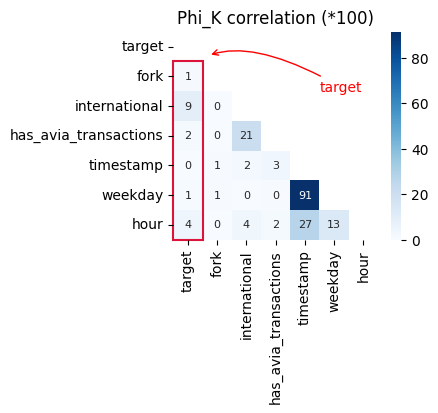

In [17]:
matrix = np.tri(len(phik_corr)).T
        
plt.figure(figsize=(3.3,2.7))
ax = sns.heatmap(phik_corr*100, mask=matrix, annot=True, cmap='Blues',
                 fmt='.0f', annot_kws={"size":8})

plt.title('Phi_K correlation (*100)')
ax.annotate('target', xy=(1.2, 0.8), xytext=(5, 2), color='red',
            arrowprops=dict(arrowstyle="->", 
                            connectionstyle="angle3, angleA=-30, angleB=20", color = 'red'))
ax.add_patch(Rectangle(( 0, 1), 1, phik_corr.shape[0]-1, fill=False,
             edgecolor='crimson', lw=1.5, clip_on=False))
plt.show()

Видим наибольшую взаимосвязь целевого признака с критерием международности.\
На втором месте время суток (часы).\
Небольшое влияние оказывают группа тестирования, была ли ранее транзакция и день недели.

## Блок 3: Продуктовое мышление

В бэклоге продакт-менеджера авиабилетов  есть идеи по увеличению конверсии новых пользователей в покупку:
* карта цен с самыми дешевыми билетами по направлениям;
* группировка прямых рейсов на странице результатов;
* подписка на цены билетов на дату.

### Задание 1

Помоги продакт-менеджеру оценить потенциал каждой из идей и приоритизировать бэклог.

#### a)

Какая клиентская проблема / потребность скрывается за каждой идеей и как много пользователей может сталкиваться с этой проблемой?

*	Карта
Потребность актуальна для путешественников, которым не столь принципиально направление, сколько цена полёта. Это могут быть люди, которые готовы улететь в новую локацию на выходные или праздничные дни (2-4 дня), а также направляющиеся в отпуск. Для них главное сменить обстановку, познакомиться с новым городом.
Карта наглядно демонстрирует город и цену; можно представить примерное время перелёта.
Доля таких авиапассажиров порядка 15%.
О типах пользователей и их количестве ниже в таблице.

*	Группировка
Наглядное сводное представление большого количества важной информации – авиакомпании, цены, время вылета.
Это удобно на одной странице видеть главную информацию.
Быстрее можно найти необходимый билет по более низкой цене.
Данный функционал будет полезен для всех пользователей.

*	Подписка
Потребность актуальна для людей, которые заранее (или значительно заранее) знают о своей поездке, примерные даты, направление. Они не торопятся с покупкой, а выжидают, когда цена будет минимальная.
Это могут быть собирающиеся в отпуск, или любители путешествовать по разным городам (как в примере с картой). Также это могут быть сотрудники компаний, которые работают в другом городе и периодически летают к родственникам в свой родной город.
Потребность актуальна примерно для 65% пассажиров. 

#### b)

На какие показатели и как сильно может повлиять предлагаемое решение проблемы?

Изменения связаны с интерфейсом. Клиенты увидят, что платформой удобно/приятно пользоваться, она информативна. Можно решить проблему за более короткий срок. Станут чаще использовать эту платформу, а не конкурентов.

* Churn Rate – уменьшится.
Все другие основные метрики увеличатся:
* Retention Rate;
* Daily/Weekly/Monthly Active Users;
* Conversion.

На сколько количественно изменятся метрики точно ответ только A/B-тестирования.\
До проведения эксперимента можно оценить уровень закрытия потребности клиента каждым из 3 предложенных функционалов, и выбрать для дальнейшего тестирования наиболее влиятельный.

#### c)

Какой принцип в итоге можно использовать, чтобы сравнить потенциал идей между собой?

Предлагаю рассчитать уровень закрытия потребности клиента каждым из предложенных функционалов.

[Скачать Excel таблицу](table.xlsx)

In [18]:
# ссылка для локальной работы, а не в GitHub
#from IPython.display import display, HTML
#display(HTML('<a href="./table.xlsx" download target="_blank"> Скачать Excel таблицу</a>'))

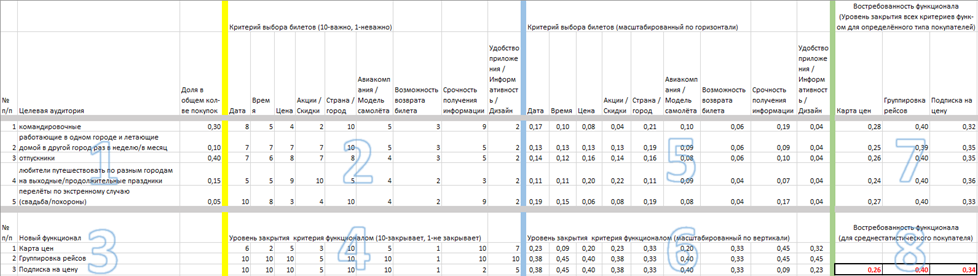

1. Определим целевую аудиторию среди авиапассажиров и доли их типов (5 шт.).
Сделал это по своей субъективной оценке (достаточно много летал), а также на основе рекомендаций генеративных моделей (DeepSeek, GPT).

    При наличии доступа к данным в Travel, возможно уточнить эти доли по следующей логике:

    * командировочные – перелёты на несколько дней по будням; к выходным возврат домой;
    * работающие в одном городе и летающие домой в другой город раз в неделю/в месяц – перелёты на выходных и праздниках на несколько дней; стабильная периодичность в течение года; одно и тоже направление;
    * отпускники – перелёт на 2-3 недели с периодичностью 1-2 раза в год;
    * любители путешествовать по разным городам на выходные/продолжительные праздники – перелёты на выходных и праздниках на несколько дней; направления разные;
    * перелёты по экстренному случаю (свадьба/похороны) – случаи редкие, можно оставить значение из предположения (5%).

2. Сформулируем критерии выбора билета (9 шт.) и степень их важности (1-10) для каждого типа пассажира.
3. Запишем варианты предлагаемого функционала.
4. Определим уровень закрытия критерия функционалом (1-10).
5. Масштабируем критерий выбора билетов. В сумме значения для определённого типа пассажира дадут 1.
6. Масштабируем уровень закрытия критерия функционалом (по вертикали). В сумме значения для одного критерия дадут 1. Важно сохранить соотношение влияния на критерий между разными функционалами.
7. Рассчитаем уровень закрытия всех критериев функционалом для определённого типа покупателей. Скалярное произведение вектора критериев типа пассажира на вектор уровней закрытия функционала.
8. Вычислим средневзвешенный уровень закрытия потребности функционалом для среднестатистического покупателя.
Скалярное произведение вектора уровней закрытия функционала на вектор долей типов покупателей.

    Полученный результат уровней закрытия (или востребованности) :

    * Группировка рейсов – 0,40;
    * Подписка на цену     – 0,34;
    * Карта цен                    – 0,26.

    Чем выше значение, тем больше новый функционал закрывает потребность покупателя и является более востребованным.


### Задание 2

Выбери из бэклога идею, получившую наибольший приоритет при выполнении предыдущего задания.

Выбираю группировку рейсов.

1)	Как бы ты валидировал эту идею (доказал, что за ней скрывается клиентская потребность / проблема)?

  Возможный предварительный анализ:
  - определить сколько пользователей выбирают прямые рейсы;
  - оценить, как часто пользователи сравнивают рейсы разных авиакомпаний;
  - посчитать, сколько времени пользователи тратят на поиск подходящего рейса.

  Соответственно, если рассчитанные показатели будут значительными, а новый функционал, очевидно, должен упростить выбор и уменьшить время покупки, то продуктовые метрики должны улучшиться.

2) Как бы ты оценил, какое влияние на показатели она может оказать (предложи способ более точной оценки, чем в предыдущем задании)?
  
   A) Предварительное пилотное тестирование. Берём 1-5% пользователей.
   Мы увидим возможный эффект от внедрения функционала.
   Эксперимент не даст статистически значимый результат, но предварительную оценку сделать возможно. 

   Также преимущества: 
   - оценка технической готовности; корректно ли работает новая функция на реальных пользователях;
   - минимизация рисков; если новая функция окажется неудачной или вызовет негативную реакцию пользователей;
   - собрать первые данные о том, как пользователи взаимодействуют с новым функционалом.

   B) Применить Machine Learning. Построить модель прогноза конверсии. Один из основных признаков – время, проведённое на сайте для подбора билета.
   То есть мы предположим, какая часть пользователей сократит время поиска билета; откорректировать у этих пользователей данные по времени.
   Обновлённую выборку пропустить через модель. 

   C) Сравнить новый функционал с ранее введёнными схожими доработками и их эффектом.
   То есть, если была похожая доработка, мы знаем эффект от неё, можно примерно спрогнозировать влияние нового функционала на метрики.

   D) Информация от конкурентов. Если схожие платформы ранее ввели подобную функцию, и есть возможность узнать результат – это будет достаточно точный прогноз эффекта.

   E) Экспертная оценка. Совещание с коллегами. Услышать мнение каждого и особенно опытных.

### Задание 3

Допустим, ты валидировал идею из предыдущего задания и оценил потенциал ее влияния на показатели продукта. Вы с продакт-менеджером решили запустить A/B-тест для проверки влияния предлагаемого решения на показатели.

1) Как бы ты подготовил А/Б-тест?

    A) Разработчики совместно с командой (PM, PA, Дизайнер и др.) создают новый функционал – страница группировки рейсов.
    
    B) Формулирование гипотез.\
    H0 – конверсии в контрольной и тестовой группе одинаковые.\
    H1 – конверсия в тестовой группе больше чем в контрольной.
    
    C) Фиксирование базовой конверсии, желаемого увеличения и уровня статистической значимости.
    
    D) Рассчитываем размер выборки и необходимое количество дней.
       Можем ускорить тестирование, направив в участвующие группы (A/B) весь поток пользователей.\
       Или можем подстраховаться и пустить на тестирование половину/треть/четверть пользователей; тест будет проходить дольше, но рисков меньше, если в продукте окажется баг.
       <br><br>
    E) В момент старта теста разработчики рандомно организуют разделение входящего трафика – кто из пользователей в какую группу направляется и соответственно видит либо старый функционал, либо новый.\
       Это разделение фиксируется, как и результат процесса взаимодействия пользователя с платформой.

2) Как бы анализировал результаты теста и какие решения принимал в зависимости от результатов?

   По результатам теста вычислим p-value – вероятность получить такую конверсию на тестовой выборке (либо ещё большую), если нулевая гипотеза H0 верна.

   Если p-value ниже принятого уровня статистической значимости, значит нулевая гипотеза отвергается в пользу альтернативной. Новый функционал можно внедрять для всего трафика.

   Если p-value выше уровня статистической значимости – нулевая гипотеза не отвергается.
   Новый функционал пока не внедряется и анализируется причина, почему не произошло статистически значимое улучшение.
   
   Возможные варианты:
   - неправильный расчёт продуктового аналитика, что этот функционал должен привести к положительному результату; необходимо понять в каком месте была ошибка;
   - баг в программной реализации; сайт зависал, пользователь уходил к конкуренту.

    После нахождения ошибок и просчётов, их исправления, принять решение о целесообразности запуска теста повторно.

## Блок 4: Анализ изменения выдачи

### Интро

Представь, что к тебе обратился продакт-менеджер с просьбой оценить, как изменится поисковая выдача в разделе Авиа, если мы увеличим цену авиакомпании Qatar Airways на 1%.\
Твоя задача – проанализировать текущую выдачу и выяснить, как изменение цены одной авиакомпании может повлиять на всю выдачу. 

Таблица содержит данные о просмотрах поисковой выдачи пользователями. Каждое событие фиксируется при каждом новом поисковом запросе. Поисковая выдача в разделе авиа по умолчанию сортируется по возрастанию цены.
Важно учитывать, что большинство покупателей предпочитают приобретать самые дешевые билеты.

### Анализ исходных данных

In [19]:
import ast
import json
from pandas.plotting import table

In [20]:
def gaps(df):
    '''выводит сумму и долю пропусков; на входе dataframe'''
    display(pd.DataFrame(df.isna().sum(),  columns = ['sum']).join(
            pd.DataFrame(df.isna().mean(), columns = ['share'])).
            style.format({'sum':'{:.0f}', 'share':'{:.2f}'}).background_gradient())

In [21]:
def description(feature, title=''):
    '''По Series-признаку рисует диаграмму размаха, гистограмму и таблицу с точным статистиками'''
    f, ax = plt.subplots(2,2, sharex=True, gridspec_kw={"height_ratios": (.15, .85), 
                                                        "width_ratios": (0.85, 0.15)}, figsize=(9,3.5))
    sns.boxplot(x=feature, ax=ax[0,0])
    sns.histplot(x=feature, bins=100, ax=ax[1,0], element="step",alpha=0.3)
    ax[0,1].remove()
    table(data=feature.describe().astype(int), ax=ax[1,1], loc='right',colWidths=[1.8])
    
    ax[0,0].set(yticks=[], xlabel=None)
    sns.despine(ax=ax[1,0])
    sns.despine(ax=ax[0,0], left=True)
    plt.axis('off')
    f.suptitle(title)

In [22]:
df_ = pd.read_csv('qatar_results_test.csv', sep=';')

In [23]:
df_.head()

,search_id,result_array
0,dfe81f7ba79343229362a4123ab873a5,"[{""airlines"":[""British Airways""],""listingPosit..."
1,1a322347abdd4c8cbdd2fcdb8371c946,"[{""airlines"":[""British Airways""],""listingPosit..."
2,0701002ea00f45bdb4fbe10385fd8943,"[{""airlines"":[""Qatar Airways""],""listingPositio..."
3,0eadd53f7d8547a5a6211b48f46a76e1,"[{""airlines"":[""Emirates""],""listingPosition"":0,..."
4,66d3bc25a45b4f6d812b13681b4e431d,"[{'price': 20743, 'airlines': ['British Airway..."


In [24]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   search_id     100000 non-null  object
 1   result_array  100000 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [25]:
# Проверка, какие получились типы данных
df_['result_array'].apply(lambda x: type(x)).unique()

array([<class 'str'>], dtype=object)

В `result_array` исходные данные представлены в виде строк.\
Кроме того, в процессе работы над заданием выяснилось, что данные записаны в трёх форматах, каждый из которых требует определённой обработки.

In [26]:
# единичный словарь (результат запроса - одна позиция)
df_['result_array'][8]

"{'price': 15000, 'airlines': ['Qatar Airways'], 'listingPosition': 0}"

In [27]:
# список словарей (результат запроса - несколько позиций)
df_['result_array'][3593]

"[{'airlines': ['British Airways'], 'price': 23743, 'listingPosition': 0}, {'airlines': ['British Airways'], 'price': 26743, 'listingPosition': 1}, {'price': 27036, 'airlines': ['Emirates'], 'listingPosition': 2}, {'airlines': ['British Airways'], 'price': 29743, 'listingPosition': 3}, {'airlines': ['British Airways'], 'price': 29743, 'listingPosition': 4}, {'price': 30203, 'airlines': ['Qatar Airways'], 'listingPosition': 5}, {'airlines': ['Emirates'], 'price': 32336, 'listingPosition': 6}, {'airlines': ['Delta Airlines'], 'price': 36837, 'listingPosition': 7}, {'airlines': ['Delta Airlines'], 'price': 36837, 'listingPosition': 8}, {'airlines': ['Delta Airlines'], 'price': 36837, 'listingPosition': 9}]"

In [28]:
# список словарей, содержащий экранированные кавычками
df_['result_array'][3594]

'[\'{"airlines":["Emirates"],"listingPosition":0,"price":20159}\', \'{"airlines":["Qatar Airways"],"listingPosition":1,"price":29606}\', \'{"airlines":["Emirates"],"listingPosition":2,"price":60656}\', \'{"airlines":["Emirates"],"listingPosition":3,"price":60656}\', \'{"airlines":["Qatar Airways"],"listingPosition":4,"price":60741}\']'

In [29]:
def str_in_list_of_dict(result_str):
    '''Преобразует строку в список словарей. На входе могут быть: единичный словарь; список словарей; 
       список словарей, содержащий экранированные кавычками'''
    result = ast.literal_eval(result_str)
    if isinstance(result, dict):
        return [result]
    return [json.loads(item) if isinstance(item, str) else item for item in result]

In [30]:
# преобразуем из строчного формата в список словарей
df_['result_array'] = df_['result_array'].apply(str_in_list_of_dict)

In [31]:
# Развертывание списка словарей в отдельные строки
exploded_df = df_.explode('result_array')
exploded_df.head()

,search_id,result_array
0,dfe81f7ba79343229362a4123ab873a5,"{'airlines': ['British Airways'], 'listingPosi..."
0,dfe81f7ba79343229362a4123ab873a5,"{'airlines': ['British Airways'], 'listingPosi..."
0,dfe81f7ba79343229362a4123ab873a5,"{'airlines': ['British Airways'], 'listingPosi..."
0,dfe81f7ba79343229362a4123ab873a5,"{'airlines': ['Emirates'], 'listingPosition': ..."
0,dfe81f7ba79343229362a4123ab873a5,"{'airlines': ['British Airways'], 'listingPosi..."


In [32]:
# Преобразование словарей в столбцы
result_df = pd.json_normalize(exploded_df['result_array'])
result_df.head()

,airlines,listingPosition,price
0,[British Airways],0,17743
1,[British Airways],1,17743
2,[British Airways],2,17743
3,[Emirates],3,19616
4,[British Airways],4,20743


In [33]:
# Объединение с исходным DataFrame
df = pd.concat([exploded_df[['search_id']].reset_index(drop=True), result_df], axis=1)
df.head(20)

,search_id,airlines,listingPosition,price
0,dfe81f7ba79343229362a4123ab873a5,[British Airways],0,17743
1,dfe81f7ba79343229362a4123ab873a5,[British Airways],1,17743
2,dfe81f7ba79343229362a4123ab873a5,[British Airways],2,17743
3,dfe81f7ba79343229362a4123ab873a5,[Emirates],3,19616
4,dfe81f7ba79343229362a4123ab873a5,[British Airways],4,20743
5,dfe81f7ba79343229362a4123ab873a5,[Delta Airlines],5,20837
6,dfe81f7ba79343229362a4123ab873a5,[Delta Airlines],6,20837
7,dfe81f7ba79343229362a4123ab873a5,[Qatar Airways],7,22272
8,dfe81f7ba79343229362a4123ab873a5,[Emirates],8,22796
9,dfe81f7ba79343229362a4123ab873a5,[Emirates],9,22796


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823319 entries, 0 to 823318
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   search_id        823319 non-null  object
 1   airlines         823319 non-null  object
 2   listingPosition  823319 non-null  int64 
 3   price            823319 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 25.1+ MB


In [35]:
df.airlines.value_counts()   # возможные значения в airlines

airlines
[British Airways]                       291494
[Delta Airlines]                        222157
[Emirates]                              197367
[Qatar Airways]                         108398
[American Airlines]                       2501
[Delta Airlines, American Airlines]        811
[American Airlines, Delta Airlines]        516
[Delta Airlines, Singapore Airlines]        32
[Singapore Airlines, Delta Airlines]        17
[Air France]                                17
[British Airways, Emirates]                  5
[Emirates, Delta Airlines]                   3
[Air France, Delta Airlines]                 1
Name: count, dtype: int64

In [36]:
# в airlines уберём дубликаты сортировкой и переведём в строчный формат
df['airlines'] = df.airlines[~df.airlines.isna()].apply(lambda x: ','.join(sorted(x)))

In [37]:
# количество полных дубликатов
df[df.duplicated()].shape[0]

42640

In [38]:
# один из задублированных запросов
duplicate_example = df[df.duplicated()].head(1)['search_id'].item()
df.query('search_id==@duplicate_example')

,search_id,airlines,listingPosition,price
353,a7bfa3b4f80e4d939d876387f40f0904,Emirates,0,9016
354,a7bfa3b4f80e4d939d876387f40f0904,Emirates,1,11136
355,a7bfa3b4f80e4d939d876387f40f0904,Emirates,2,11136
356,a7bfa3b4f80e4d939d876387f40f0904,Emirates,3,11136
357,a7bfa3b4f80e4d939d876387f40f0904,Emirates,4,13256
358,a7bfa3b4f80e4d939d876387f40f0904,British Airways,5,14743
359,a7bfa3b4f80e4d939d876387f40f0904,British Airways,6,14743
360,a7bfa3b4f80e4d939d876387f40f0904,British Airways,7,14743
361,a7bfa3b4f80e4d939d876387f40f0904,British Airways,8,14743
362,a7bfa3b4f80e4d939d876387f40f0904,Qatar Airways,9,22272


Посмотри этот запрос в исходной таблице.

In [39]:
df_.query('search_id==@duplicate_example')

,search_id,result_array
57,a7bfa3b4f80e4d939d876387f40f0904,"[{'airlines': ['Emirates'], 'price': 9016, 'li..."
58,a7bfa3b4f80e4d939d876387f40f0904,"[{'airlines': ['Emirates'], 'price': 9016, 'li..."


In [40]:
df_.loc[57, 'result_array']

[{'airlines': ['Emirates'], 'price': 9016, 'listingPosition': 0},
 {'airlines': ['Emirates'], 'price': 11136, 'listingPosition': 1},
 {'airlines': ['Emirates'], 'price': 11136, 'listingPosition': 2},
 {'price': 11136, 'airlines': ['Emirates'], 'listingPosition': 3},
 {'price': 13256, 'airlines': ['Emirates'], 'listingPosition': 4},
 {'price': 14743, 'airlines': ['British Airways'], 'listingPosition': 5},
 {'airlines': ['British Airways'], 'price': 14743, 'listingPosition': 6},
 {'price': 14743, 'airlines': ['British Airways'], 'listingPosition': 7},
 {'airlines': ['British Airways'], 'price': 14743, 'listingPosition': 8},
 {'price': 22272, 'airlines': ['Qatar Airways'], 'listingPosition': 9}]

In [41]:
df_.loc[58, 'result_array']

[{'airlines': ['Emirates'], 'price': 9016, 'listingPosition': 0},
 {'price': 11136, 'airlines': ['Emirates'], 'listingPosition': 1},
 {'airlines': ['Emirates'], 'price': 11136, 'listingPosition': 2},
 {'airlines': ['Emirates'], 'price': 11136, 'listingPosition': 3},
 {'airlines': ['Emirates'], 'price': 13256, 'listingPosition': 4},
 {'price': 14743, 'airlines': ['British Airways'], 'listingPosition': 5},
 {'airlines': ['British Airways'], 'price': 14743, 'listingPosition': 6},
 {'price': 14743, 'airlines': ['British Airways'], 'listingPosition': 7},
 {'airlines': ['British Airways'], 'price': 14743, 'listingPosition': 8},
 {'airlines': ['Qatar Airways'], 'price': 22272, 'listingPosition': 9}]

Идентичные значения за исключением разной сортировки в словарях.\
Удалим дубликаты.

In [42]:
df.drop_duplicates(inplace=True)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780679 entries, 0 to 823308
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   search_id        780679 non-null  object
 1   airlines         780679 non-null  object
 2   listingPosition  780679 non-null  int64 
 3   price            780679 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 29.8+ MB


Таким образов, резюме по количеству строк:
* исходный df_ - 100000;
* исходный df_ после распаковки - 823319;
* удалённые с дубликатами - 42640.

In [44]:
print(f'Размер итогового df: {823319-42640}')
print(f'После очистки от дубликатов датасет уменьшился на {1-(823319-42640)/823319:.0%}')

Размер итогового df: 780679
После очистки от дубликатов датасет уменьшился на 5%


In [45]:
df.search_id.nunique() # количество исследуемых запросов

95355

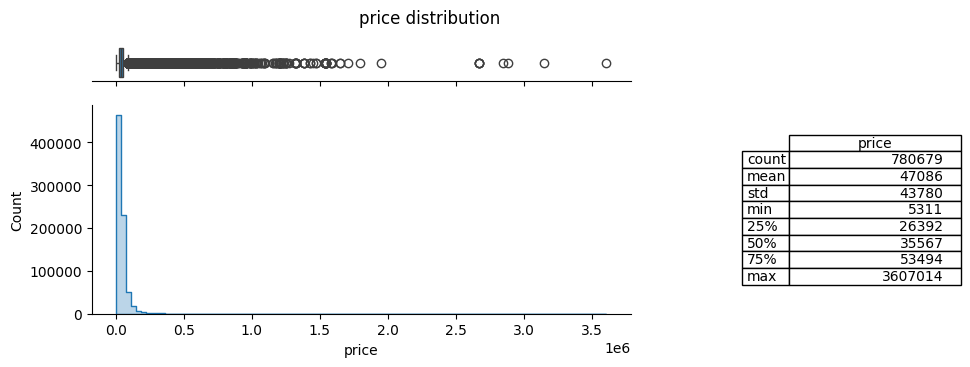

In [46]:
description(df.price, title='price distribution')

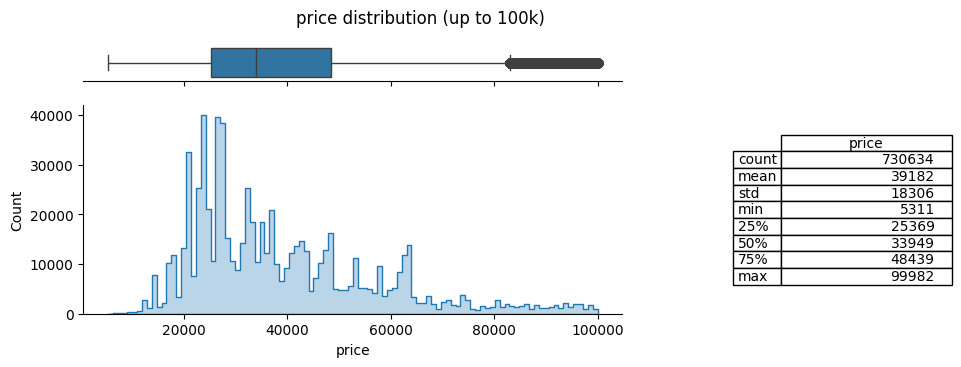

In [47]:
description(df.price[df.price<100000], title='price distribution (up to 100k)')

Распределение стоимости правдоподобно.

In [48]:
df.listingPosition.unique() # уникальные значения в listingPosition

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Проверим, что listingPosition по каждому запросу представляет последовательный непрерывный набор неотрицательных целых чисел от 0 и выше.

In [49]:
# по каждому запросу определим максимальное значение listingPosition, сумму, число результатов
df_search_id = df.groupby('search_id')['listingPosition'].agg(['max', 'sum', 'count'])

In [50]:
df_search_id['sum_from_0_to_max']          = df_search_id['max'].apply(lambda x: sum(range(0,x+1)))
df_search_id['length_of_correct_sequence'] = df_search_id['max'].apply(lambda x: len(range(0,x+1)))

In [51]:
df_search_id.head()

,max,sum,count,sum_from_0_to_max,length_of_correct_sequence
search_id,,,,,
0001c7f742e348ebb7004c71faf09826,9,45,10,45,10
00021aaaaf80498f9fdfef005b6da565,9,45,10,45,10
000291b9c2764b789dee2a83e45658c7,9,45,10,45,10
00032ad1bad54f6b995fa20884dc7fd6,9,45,10,45,10
0003480ff73a42749f44b5a53dee5fec,9,45,10,45,10


Если значения в столбцах `sum` и `sum_from_0_to_max`, а также `count` и `length_of_correct_sequence` равны, значит последовательность listingPosition без аномалий и начинается с 0.

In [52]:
# число аномалий в listingPosition
df_search_id.query('sum != sum_from_0_to_max').shape[0]

0

Проверим соответствуют ли `listingPosition` и `price`. Создандим новый признак ранжирования и сравним его с исходным.

In [53]:
df['listingPosition_check'] = df.groupby('search_id')['price'].rank('first').astype(int)-1
df.head()

,search_id,airlines,listingPosition,price,listingPosition_check
0,dfe81f7ba79343229362a4123ab873a5,British Airways,0,17743,0
1,dfe81f7ba79343229362a4123ab873a5,British Airways,1,17743,1
2,dfe81f7ba79343229362a4123ab873a5,British Airways,2,17743,2
3,dfe81f7ba79343229362a4123ab873a5,Emirates,3,19616,3
4,dfe81f7ba79343229362a4123ab873a5,British Airways,4,20743,4


In [54]:
# количество несоответствий между listingPosition и listingPosition_check
df.query('listingPosition != listingPosition_check').shape[0]

0

Исходное ранжирование корректно.

### Вывод по анализу исходных данных

* Исходный датасет размером 10000 строк, 2 столбца (search_id, result_array).
`result_array` в строчном формате JSON в трёх вариантах записи: единичный словарь, список словарей и список словарей с экранированными кавычками. Все варианты обработаны в тип список словарей для последующего разбиения на столбцы.
* Каждая позиция вывода запроса записана в отдельную строку. Получилось 823319 строк.
* В `airlines` убраны неявные дубликаты.
* Удалены полные дубликаты (42640 строк). В исходном файле есть идентичные позиции, отличающиеся только очерёдностью записи информации в `result_array`.\
Размер итогового df: 780679 строк.\
Количество исследуемых запросов: 95355.\
Датасет уменьшился на 5%.
* Распределение цены нормальное с выбросами в большую сторону.
* Значения в `listingPosition` корректные - от 0 до 9; ранжированы правильно.


### Задание 1

Проанализировать текущие данные поисковой выдачи.

#### a)

Какая авиакомпания чаще всего находится на первой позиции (самая дешевая)? В ответе укажи название авиакомпании, долю и количество поисков, где она занимает первую позицию.

In [55]:
top = pd.concat([
    df.query('listingPosition == 0')['airlines'].value_counts(normalize=True).round(3),
    df.query('listingPosition == 0')['airlines'].value_counts()], axis=1)
top.columns = ['share', 'amount']
top

,share,amount
airlines,,
British Airways,0.438,41761
Emirates,0.273,26071
Qatar Airways,0.244,23233
Delta Airlines,0.045,4284
"British Airways,Emirates",0.000,3
"Delta Airlines,Emirates",0.000,3


British Airways чаще всего на первой позиции.\
Занимаемая доля: 0.438.\
Количество: 41761.


#### b)

Определи, в какой доле поисков Qatar Airways является самым дешевым. В ответе укажи долю и количество поисков, когда Qatar Airways на первой позиции.

Занимаемая доля: 0.244.\
Количество: 23233.

### Задание 2

Оценить влияние увеличения цены авиакомпании Qatar Airways на 1% на общую поисковую выдачу.

#### a)

В какой доле поисков  Qatar Airways останется на первой позиции в выдаче после увеличения цены?

In [56]:
# новый столбец с увеличенной ценой для Qatar Airways
df['price_new'] = df.apply(lambda x: int(round(x['price']*1.01))
                           if x['airlines'] == 'Qatar Airways' 
                           else x['price'], axis=1)

In [57]:
# новый столбец с обновлёнными позициями в выдаче после корректировки цены
df['listingPosition_new'] = df.groupby('search_id')['price_new'].rank('first').astype(int)-1
df.head()

,search_id,airlines,listingPosition,price,listingPosition_check,price_new,listingPosition_new
0,dfe81f7ba79343229362a4123ab873a5,British Airways,0,17743,0,17743,0
1,dfe81f7ba79343229362a4123ab873a5,British Airways,1,17743,1,17743,1
2,dfe81f7ba79343229362a4123ab873a5,British Airways,2,17743,2,17743,2
3,dfe81f7ba79343229362a4123ab873a5,Emirates,3,19616,3,19616,3
4,dfe81f7ba79343229362a4123ab873a5,British Airways,4,20743,4,20743,4


In [58]:
top_new = pd.concat([
    df.query('listingPosition_new == 0')['airlines'].value_counts(normalize=True).round(3),
    df.query('listingPosition_new == 0')['airlines'].value_counts()], axis=1)
top_new.columns = ['share', 'amount']
top_new

,share,amount
airlines,,
British Airways,0.439,41869
Emirates,0.281,26759
Qatar Airways,0.231,22059
Delta Airlines,0.049,4662
"British Airways,Emirates",0.000,3
"Delta Airlines,Emirates",0.000,3


После увеличения цены доля, которую Qatar Airways занимает среди первого места выдачи: 0.231.

#### b)

В какой доле поисков Qatar Airways потеряет первую позицию после изменения цены?

$ \frac{количество\ первых\ позиций\ в\ старой\ выдаче\ -\ количество\ первых\ позиций\ в\ новой\ выдаче}{общее\ число\ запросов}\\ $

In [59]:
round((top.loc['Qatar Airways','amount']-top_new.loc['Qatar Airways','amount'])/top['amount'].sum(), 3).item()

0.012

После изменения цены Qatar Airways потеряет первую позицию относительно всех запросов в доле: 0.012.

#### c)

Дополнительно также можно посчитать доли изменений не относительно всех запросов, а только относительно базовой существующей выдачи Qatar Airways.

Доля оставшихся топовых выдачей:

In [60]:
round(top_new.loc['Qatar Airways','amount']/top.loc['Qatar Airways','amount'], 3).item()

0.949

Доля потерянных топовых выдачей:

In [61]:
round((top.loc['Qatar Airways','amount']-top_new.loc['Qatar Airways','amount'])/top.loc['Qatar Airways','amount'], 3).item()

0.051